# WiFi-CSI Human Pose Estimation

**Option 2: A practical machine-learning system**

This notebook will become the public, self-contained Assignment 2 implementation. It is intentionally not executed during the scaffold milestone.

## 0. Reproducibility
Install pinned dependencies, record runtime versions, set deterministic seeds, and download verified raw datasets.

In [2]:
import os, sys
from pathlib import Path
EXPECTED_PYTHON = Path('/data/axnguyen/Env/Anaconda/envs/ML_31005/bin/python').resolve()
ACTIVE_PYTHON = Path(sys.executable).resolve()
assert ACTIVE_PYTHON == EXPECTED_PYTHON, f'Select Python (ML_31005); active interpreter is {ACTIVE_PYTHON}'
PROJECT_ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'environment.yml').exists())
if str(PROJECT_ROOT) not in sys.path: sys.path.insert(0, str(PROJECT_ROOT))
MPL_CACHE = PROJECT_ROOT / '.cache/matplotlib'; MPL_CACHE.mkdir(parents=True, exist_ok=True)
os.environ.setdefault('MPLCONFIGDIR', str(MPL_CACHE))
print('Python:', ACTIVE_PYTHON)
print('Project:', PROJECT_ROOT)

Python: /data/axnguyen/Env/Anaconda/envs/ML_31005/bin/python3.11
Project: /data/axnguyen/31050_ML/wifi_csi_hpe


## 1.1 Wi-Pose: labelled source dataset
Wi-Pose is the supervised source dataset. Each MATLAB v7.3 file contains one five-packet CSI window and one AlphaPose-18 annotation: 18 x-coordinates, 18 y-coordinates, and 18 confidence scores. Raw `(x, y)` is preserved for modelling. Because the released camera coordinate frame appears sideways on a normal screen, a separate clockwise transform is used only for visualization.

In [3]:
import json, collections, h5py, numpy as np
source_manifest = PROJECT_ROOT / 'data/manifests/wipose_samples.jsonl'
wipose = [json.loads(line) for line in source_manifest.open(encoding='utf-8')]
print('samples:', len(wipose))
print('archive split:', collections.Counter(r['archive_split'] for r in wipose))
print('participants:', len({r['participant'] for r in wipose}))
raw_path = Path(wipose[0]['csi_path'])
with h5py.File(raw_path, 'r') as f:
    raw_csi = np.asarray(f['CSI'][()], dtype=np.float32)
    pose_vector = np.asarray(f['SkeletonPoints'][()], dtype=np.float32).reshape(3, 18)
joints_pixel = pose_vector[:2, :14].T  # official raw (x, y) target
joints_display = np.column_stack([480 - joints_pixel[:,1], joints_pixel[:,0]])  # display only
confidence = pose_vector[2, :14]
print('raw CSI:', raw_csi.shape, raw_csi.dtype)
print('body joints:', joints_pixel.shape, 'confidence:', confidence.shape)

samples: 166600
archive split: Counter({'Train': 132847, 'Test': 33753})
participants: 120
raw CSI: (3, 3, 30, 5) float32
body joints: (14, 2) confidence: (14,)


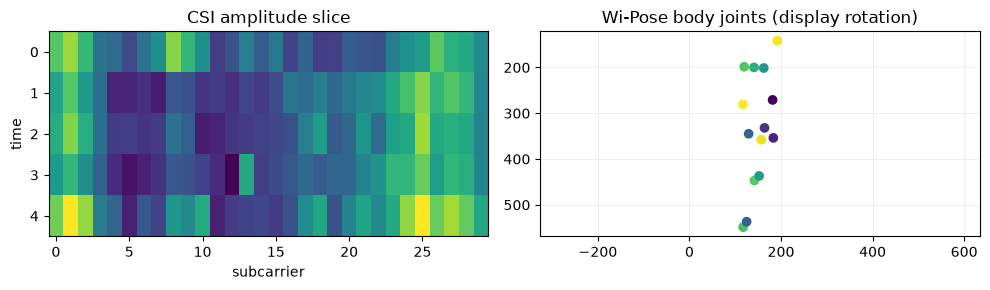

In [4]:
import matplotlib.pyplot as plt
csi = raw_csi.transpose(3, 0, 1, 2)
plt.figure(figsize=(10, 3))
plt.subplot(1, 2, 1); plt.imshow(csi[:, 0, 0, :], aspect='auto'); plt.title('CSI amplitude slice'); plt.xlabel('subcarrier'); plt.ylabel('time')
plt.subplot(1, 2, 2); plt.scatter(joints_display[:,0], joints_display[:,1], c=confidence, cmap='viridis'); plt.gca().invert_yaxis(); plt.title('Wi-Pose body joints (display rotation)'); plt.axis('equal'); plt.grid(alpha=.2)
plt.tight_layout()

### Wi-Pose distributions
The filename encodes activity, recording/participant identifier, and frame. Distribution checks reveal class imbalance, participant imbalance, and whether the supplied archive split is suitable for an HPE evaluation. The assignment will later replace the archive split with a participant-grouped 80/10/10 split to prevent adjacent frames from the same person leaking across partitions.

,sample_id,csi_path,pose_path,participant,activity,archive_split
0,bend_001-frame001,/data/axnguyen/31050_ML/wifi_csi_hpe/data/extr...,/data/axnguyen/31050_ML/wifi_csi_hpe/data/extr...,001,bend,Train
1,bend_001-frame002,/data/axnguyen/31050_ML/wifi_csi_hpe/data/extr...,/data/axnguyen/31050_ML/wifi_csi_hpe/data/extr...,001,bend,Train
2,bend_001-frame003,/data/axnguyen/31050_ML/wifi_csi_hpe/data/extr...,/data/axnguyen/31050_ML/wifi_csi_hpe/data/extr...,001,bend,Train
3,bend_001-frame004,/data/axnguyen/31050_ML/wifi_csi_hpe/data/extr...,/data/axnguyen/31050_ML/wifi_csi_hpe/data/extr...,001,bend,Train
4,bend_001-frame005,/data/axnguyen/31050_ML/wifi_csi_hpe/data/extr...,/data/axnguyen/31050_ML/wifi_csi_hpe/data/extr...,001,bend,Train


,samples,participants,activities,duplicate_ids
0,166600,120,12,0


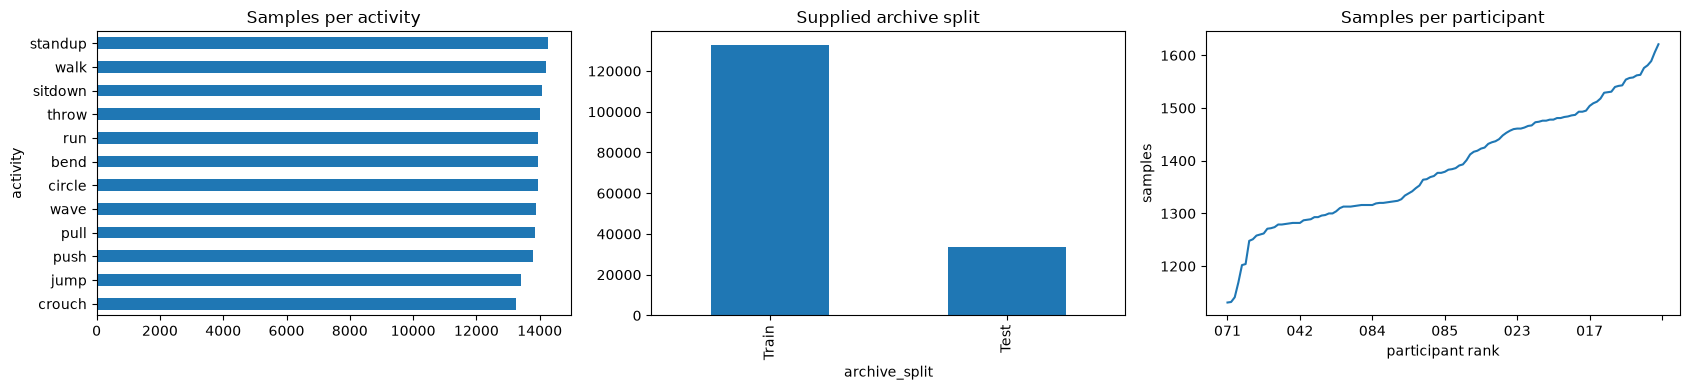

In [5]:
import pandas as pd, matplotlib.pyplot as plt, seaborn as sns
wipose_df = pd.DataFrame(wipose)
display(wipose_df.head())
summary = pd.DataFrame({
    'samples': [len(wipose_df)],
    'participants': [wipose_df.participant.nunique()],
    'activities': [wipose_df.activity.nunique()],
    'duplicate_ids': [wipose_df.sample_id.duplicated().sum()]
})
display(summary)
fig, axes = plt.subplots(1, 3, figsize=(17, 4))
wipose_df.activity.value_counts().sort_values().plot.barh(ax=axes[0], title='Samples per activity')
wipose_df.archive_split.value_counts().plot.bar(ax=axes[1], title='Supplied archive split')
wipose_df.participant.value_counts().sort_values().plot(ax=axes[2], title='Samples per participant')
axes[2].set_xlabel('participant rank'); axes[2].set_ylabel('samples')
plt.tight_layout()

### Wi-Pose signal and pose quality
A raw CSI sample has shape `(3, 3, 30, 5)`: transmit antenna, receive antenna, subcarrier, and packet. The model-facing layout is `(5, 3, 3, 30)`. Pose confidence is inspected before choosing a masking threshold. Canonical coordinates are centred on the hip midpoint and divided by neck-to-hip torso length, which removes camera translation and body-scale variation while preserving articulation.

,value
CSI minimum,0.000000
CSI maximum,46.549232
CSI mean,18.152164
CSI std,10.595465
CSI NaNs,0.000000
mean pose confidence,0.616517
minimum pose confidence,0.308481
torso scale,138.634308


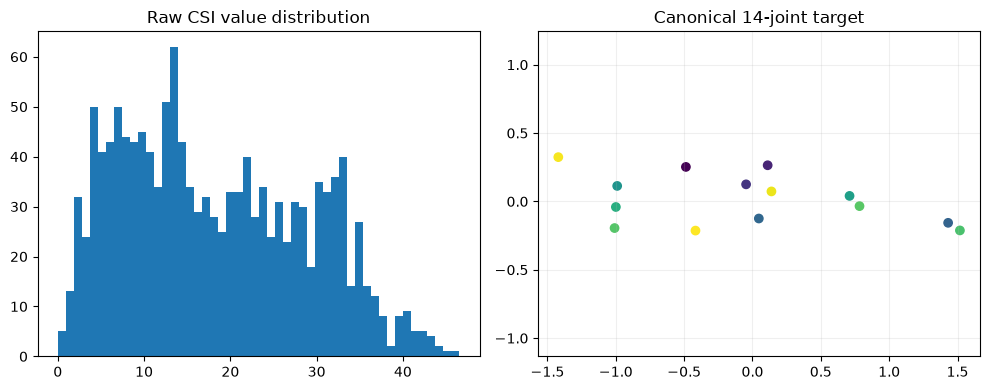

In [6]:
hip_midpoint = (joints_pixel[8] + joints_pixel[11]) / 2
torso = max(np.linalg.norm(joints_pixel[1] - hip_midpoint), 1.0)
joints_canonical = (joints_pixel - hip_midpoint) / torso
quality = pd.Series({
    'CSI minimum': float(np.nanmin(raw_csi)), 'CSI maximum': float(np.nanmax(raw_csi)),
    'CSI mean': float(np.nanmean(raw_csi)), 'CSI std': float(np.nanstd(raw_csi)),
    'CSI NaNs': int(np.isnan(raw_csi).sum()), 'mean pose confidence': float(confidence.mean()),
    'minimum pose confidence': float(confidence.min()), 'torso scale': float(torso)
})
display(quality.to_frame('value'))
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(raw_csi.ravel(), bins=50); axes[0].set_title('Raw CSI value distribution')
axes[1].scatter(joints_canonical[:, 0], -joints_canonical[:, 1], c=confidence, cmap='viridis')
axes[1].set_title('Canonical 14-joint target'); axes[1].axis('equal'); axes[1].grid(alpha=.2)
plt.tight_layout()

### Wi-Pose CSI–skeleton sequence example
Each Wi-Pose file aligns one skeleton frame with five CSI packets. The [official Wi-Pose release](https://github.com/NjtechCVLab/Wi-PoseDataset) states that synchronized camera images were processed by AlphaPose to create 18 coordinate and confidence labels. These are camera-derived supervision, not manually verified ground truth. Confidence measures the pose estimator's certainty and can mask or down-weight unreliable joints during training. The display uses a shoulder–hip torso outline rather than OpenPose's visually confusing direct neck-to-hip links.

,sample_id,activity,participant,frame,packet_start,packet_end
161397,walk_029-frame001,walk,029,1,0,4
161398,walk_029-frame002,walk,029,2,5,9
161399,walk_029-frame003,walk,029,3,10,14
161400,walk_029-frame004,walk,029,4,15,19
161401,walk_029-frame005,walk,029,5,20,24
161402,walk_029-frame006,walk,029,6,25,29
161403,walk_029-frame007,walk,029,7,30,34
161404,walk_029-frame008,walk,029,8,35,39


CSI: (40, 30); skeletons: (8, 18, 2)


,joint_index,joint_name
0,0,nose
1,1,neck
2,2,right shoulder
3,3,right elbow
4,4,right wrist
5,5,left shoulder
6,6,left elbow
7,7,left wrist
8,8,right hip
9,9,right knee


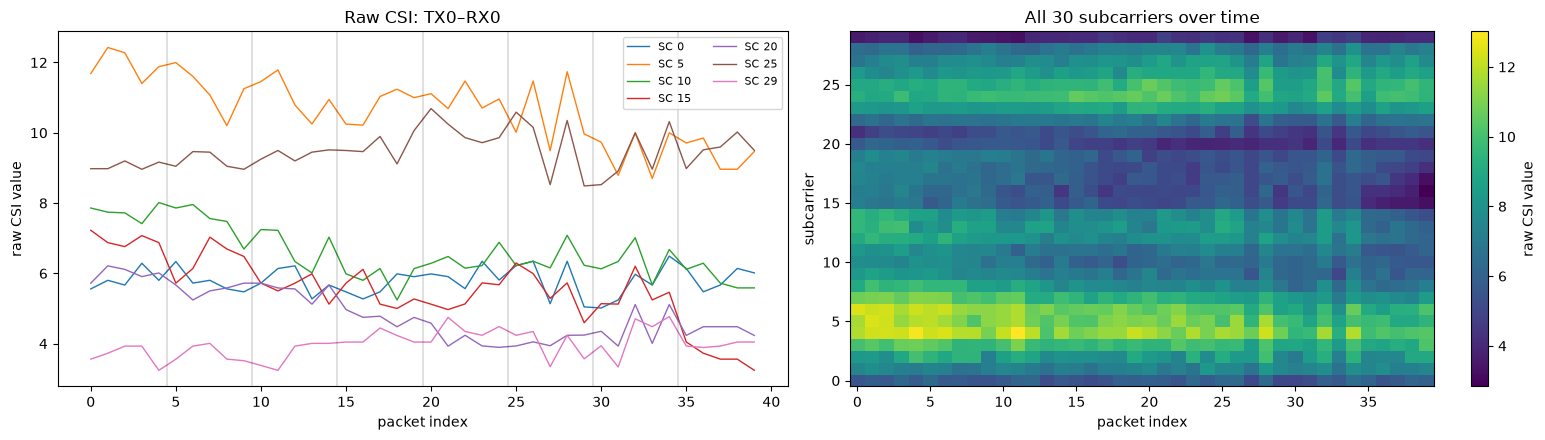

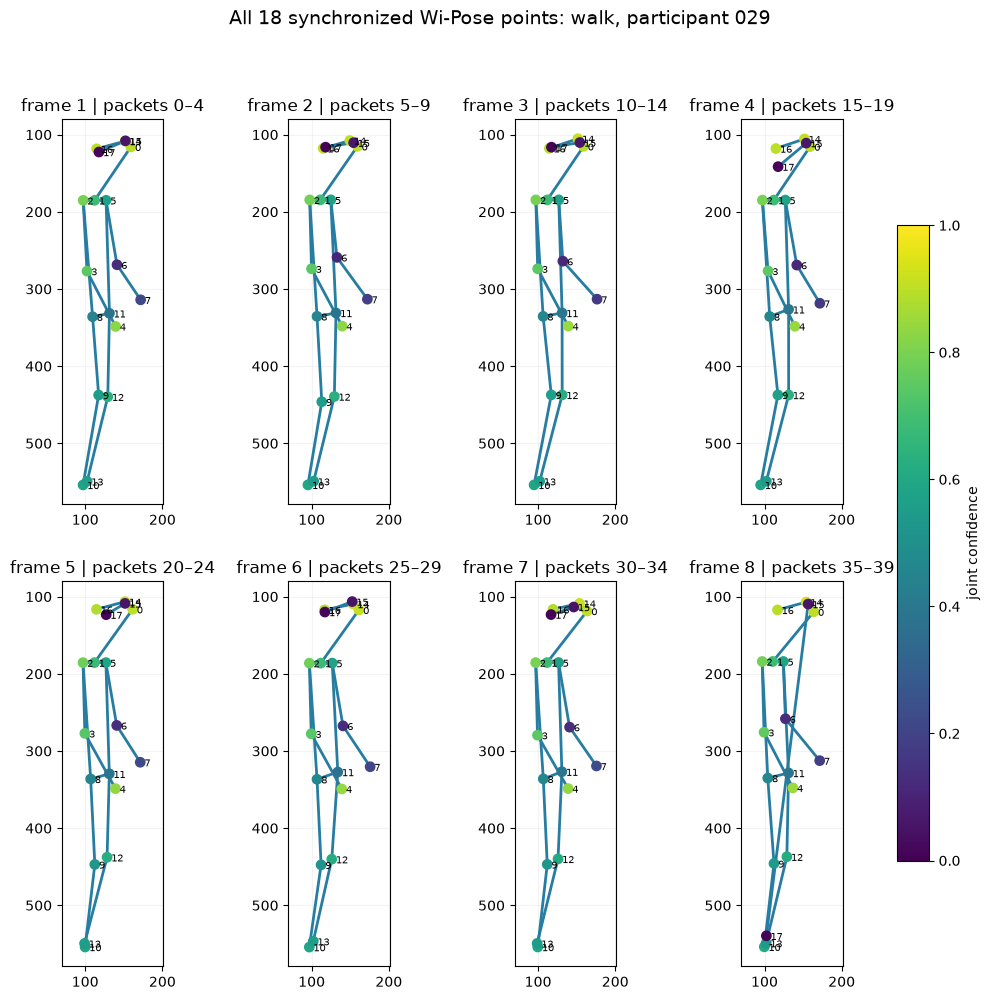

In [7]:
SEQUENCE_ACTIVITY = 'walk'
SEQUENCE_PARTICIPANT = None  # Example: '009'; None selects the longest matching sequence.
N_SEQUENCE_FRAMES = 8
TX_INDEX, RX_INDEX = 0, 0
SUBCARRIERS_TO_PLOT = [0, 5, 10, 15, 20, 25, 29]
sequence_index = wipose_df.copy()
sequence_index['frame'] = sequence_index.sample_id.str.extract(r'-frame(\d+)$')[0].astype(int)
candidates = sequence_index[sequence_index.activity.eq(SEQUENCE_ACTIVITY)]
if SEQUENCE_PARTICIPANT is None: SEQUENCE_PARTICIPANT = candidates.participant.value_counts().index[0]
sequence = candidates[candidates.participant.eq(SEQUENCE_PARTICIPANT)].sort_values('frame').iloc[:N_SEQUENCE_FRAMES].copy()
if sequence.empty: raise ValueError('No matching sequence; check activity and participant.')
csi_windows, skeletons, confidences = [], [], []
for path_text in sequence.csi_path:
    with h5py.File(path_text, 'r') as f:
        raw = np.asarray(f['CSI'][()], dtype=np.float32)
        pose = np.asarray(f['SkeletonPoints'][()], dtype=np.float32).reshape(3, 18)
    csi_windows.append(raw[TX_INDEX, RX_INDEX].T)
    raw_joints=pose[:2,:].T
    skeletons.append(np.column_stack([480-raw_joints[:,1],raw_joints[:,0]])); confidences.append(pose[2,:])
csi_sequence = np.concatenate(csi_windows, axis=0)
skeletons, confidences = np.stack(skeletons), np.stack(confidences)
sequence['packet_start'] = np.arange(len(sequence)) * 5; sequence['packet_end'] = sequence.packet_start + 4
display(sequence[['sample_id','activity','participant','frame','packet_start','packet_end']])
print(f'CSI: {csi_sequence.shape}; skeletons: {skeletons.shape}')
JOINT_NAMES = ['nose','neck','right shoulder','right elbow','right wrist','left shoulder','left elbow','left wrist','right hip','right knee','right ankle','left hip','left knee','left ankle','right eye','left eye','right ear','left ear']
BODY18_EDGES = [(0,1),(1,2),(2,3),(3,4),(1,5),(5,6),(6,7),(2,8),(8,9),(9,10),(5,11),(11,12),(12,13),(2,5),(8,11),(0,14),(14,16),(0,15),(15,17)]
display(pd.DataFrame({'joint_index': range(18), 'joint_name': JOINT_NAMES}))
fig, (ax, ax_heat) = plt.subplots(1, 2, figsize=(16, 4.5))
for sc in SUBCARRIERS_TO_PLOT: ax.plot(csi_sequence[:,sc], label=f'SC {sc}', linewidth=1)
for boundary in range(5,len(csi_sequence),5): ax.axvline(boundary-.5,color='k',alpha=.12)
ax.set(title=f'Raw CSI: TX{TX_INDEX}–RX{RX_INDEX}',xlabel='packet index',ylabel='raw CSI value'); ax.legend(ncol=2,fontsize=8)
image=ax_heat.imshow(csi_sequence.T,aspect='auto',origin='lower',cmap='viridis')
ax_heat.set(title='All 30 subcarriers over time',xlabel='packet index',ylabel='subcarrier'); fig.colorbar(image,ax=ax_heat,label='raw CSI value')
plt.tight_layout(); plt.show()
fig, axes = plt.subplots(2, 4, figsize=(14, 11), squeeze=False)
x_min,x_max=skeletons[:,:,0].min(),skeletons[:,:,0].max(); y_min,y_max=skeletons[:,:,1].min(),skeletons[:,:,1].max(); padding=25
for i,(joints,conf,pose_ax) in enumerate(zip(skeletons,confidences,axes.flat)):
    for a,b in BODY18_EDGES: pose_ax.plot(joints[[a,b],0],joints[[a,b],1],color='#277da1',linewidth=2)
    points=pose_ax.scatter(joints[:,0],joints[:,1],c=conf,cmap='viridis',vmin=0,vmax=1,s=45,zorder=3)
    for joint_id,(x,y) in enumerate(joints): pose_ax.annotate(str(joint_id),(x,y),xytext=(3,-3),textcoords='offset points',fontsize=7)
    pose_ax.set_title(f"frame {sequence.iloc[i].frame} | packets {sequence.iloc[i].packet_start}–{sequence.iloc[i].packet_end}")
    pose_ax.set_aspect('equal'); pose_ax.set_xlim(x_min-padding,x_max+padding); pose_ax.set_ylim(y_max+padding,y_min-padding); pose_ax.grid(alpha=.15)
fig.suptitle(f'All 18 synchronized Wi-Pose points: {SEQUENCE_ACTIVITY}, participant {SEQUENCE_PARTICIPANT}',fontsize=14)
fig.colorbar(points,ax=axes.ravel().tolist(),label='joint confidence',shrink=.75); plt.show()

### Full AlphaPose-labelled skeleton video
Matplotlib can animate the complete selected Wi-Pose sequence inline. The left panel shows all 18 ground-truth points and bones. The right panel shows the raw 30-subcarrier CSI heatmap with a moving cursor at the five packets associated with the current skeleton frame. `VIDEO_FPS` controls playback speed; it is a visualization setting, not a claim about the dataset capture rate. Set `SAVE_MP4=True` to write the same animation under `results/figures/`.

In [8]:
from matplotlib import animation
from IPython.display import HTML
VIDEO_FPS = 20
VIDEO_MAX_FRAMES = None  # None uses the full matching recording.
SAVE_MP4 = False
video_sequence = candidates[candidates.participant.eq(SEQUENCE_PARTICIPANT)].sort_values('frame').copy()
if VIDEO_MAX_FRAMES is not None: video_sequence = video_sequence.iloc[:VIDEO_MAX_FRAMES]
video_skeletons, video_confidence, video_csi = [], [], []
for path_text in video_sequence.csi_path:
    with h5py.File(path_text, 'r') as f:
        raw = np.asarray(f['CSI'][()], dtype=np.float32)
        pose = np.asarray(f['SkeletonPoints'][()], dtype=np.float32).reshape(3, 18)
    raw_joints=pose[:2,:].T
    video_skeletons.append(np.column_stack([480-raw_joints[:,1],raw_joints[:,0]]))
    video_confidence.append(pose[2,:])
    video_csi.append(raw[TX_INDEX,RX_INDEX].T)
video_skeletons=np.stack(video_skeletons); video_confidence=np.stack(video_confidence); video_csi=np.concatenate(video_csi)
fig,(pose_ax,csi_ax)=plt.subplots(1,2,figsize=(13,5.5),gridspec_kw={'width_ratios':[1,1.5]})
vx0,vx1=video_skeletons[:,:,0].min()-25,video_skeletons[:,:,0].max()+25
vy0,vy1=video_skeletons[:,:,1].min()-25,video_skeletons[:,:,1].max()+25
pose_ax.set(xlim=(vx0,vx1),ylim=(vy1,vy0),aspect='equal',xlabel='image x',ylabel='image y')
pose_ax.grid(alpha=.15); bone_lines=[pose_ax.plot([],[],color='#277da1',linewidth=2)[0] for _ in BODY18_EDGES]
joint_scatter=pose_ax.scatter([],[],c=[],cmap='viridis',vmin=0,vmax=1,s=55,zorder=3)
joint_labels=[pose_ax.text(0,0,str(i),fontsize=7) for i in range(18)]
heat=csi_ax.imshow(video_csi.T,aspect='auto',origin='lower',cmap='viridis')
cursor=csi_ax.axvspan(0,4,color='red',alpha=.22); csi_ax.set(xlabel='packet index',ylabel='subcarrier',title=f'Raw CSI TX{TX_INDEX}–RX{RX_INDEX}')
fig.colorbar(heat,ax=csi_ax,label='raw CSI value')
def update_video(i):
    global cursor
    joints=video_skeletons[i]; conf=video_confidence[i]
    for line,(a,b) in zip(bone_lines,BODY18_EDGES): line.set_data(joints[[a,b],0],joints[[a,b],1])
    joint_scatter.set_offsets(joints); joint_scatter.set_array(conf)
    for label,(x,y) in zip(joint_labels,joints): label.set_position((x+3,y-3))
    cursor.remove(); cursor=csi_ax.axvspan(i*5,i*5+4,color='red',alpha=.22)
    row=video_sequence.iloc[i]
    pose_ax.set_title(f"{row.activity} | participant {row.participant} | frame {row.frame} | mean confidence {conf.mean():.2f}")
    return [*bone_lines,joint_scatter,*joint_labels,cursor]
ground_truth_video=animation.FuncAnimation(fig,update_video,frames=len(video_sequence),interval=1000/VIDEO_FPS,blit=False,repeat=True)
plt.close(fig)
if SAVE_MP4:
    video_dir=PROJECT_ROOT/'results/figures'; video_dir.mkdir(parents=True,exist_ok=True)
    video_path=video_dir/f"wipose_{SEQUENCE_ACTIVITY}_{SEQUENCE_PARTICIPANT}_ground_truth.mp4"
    ground_truth_video.save(video_path,writer='ffmpeg',fps=VIDEO_FPS,dpi=130); print('saved:',video_path)
HTML(ground_truth_video.to_html5_video())

### Random full-recording skeleton and CSI video
This cell mirrors the full-recording behavior of Cell 14 but chooses a new action/recording pair on every execution. It loads every frame in that recording, renders all 18 AlphaPose-labelled points, and moves a cursor across the complete CSI timeline. Wi-Pose filenames expose recording identifiers rather than a verified volunteer-identity field, so the displayed `recording` value must not be interpreted as a person ID.

In [9]:
from matplotlib import animation
from IPython.display import HTML
RANDOM_FULL_VIDEO_SEED = None  # None gives a new recording each run; use an integer to reproduce it.
RANDOM_FULL_VIDEO_FPS = 20
SAVE_RANDOM_FULL_VIDEO = False
random_full_rng=np.random.default_rng(RANDOM_FULL_VIDEO_SEED)
full_candidates=(wipose_df.groupby(['activity','participant']).size().reset_index(name='frames'))
full_choice=full_candidates.iloc[random_full_rng.integers(len(full_candidates))]
random_full_rows=wipose_df[(wipose_df.activity==full_choice.activity)&(wipose_df.participant==full_choice.participant)].copy()
random_full_rows['frame']=random_full_rows.sample_id.str.extract(r'-frame(\d+)$')[0].astype(int)
random_full_rows=random_full_rows.sort_values('frame').reset_index(drop=True)
random_full_skeletons,random_full_confidence,random_full_csi=[],[],[]
for row in random_full_rows.itertuples():
    with h5py.File(row.csi_path,'r') as f:
        raw=np.asarray(f['CSI'][()],dtype=np.float32)
        pose=np.asarray(f['SkeletonPoints'][()],dtype=np.float32).reshape(3,18)
    raw_joints=pose[:2,:].T
    random_full_skeletons.append(np.column_stack([480-raw_joints[:,1],raw_joints[:,0]]))
    random_full_confidence.append(pose[2,:]); random_full_csi.append(raw[TX_INDEX,RX_INDEX].T)
random_full_skeletons=np.stack(random_full_skeletons); random_full_confidence=np.stack(random_full_confidence); random_full_csi=np.concatenate(random_full_csi)
display(pd.DataFrame({'action':[full_choice.activity],'recording':[full_choice.participant],'first_frame':[random_full_rows.frame.iloc[0]],'last_frame':[random_full_rows.frame.iloc[-1]],'skeleton_frames':[len(random_full_rows)],'CSI_packets':[len(random_full_csi)]}))
fig,(random_pose_ax,random_csi_ax)=plt.subplots(1,2,figsize=(13,5.5),gridspec_kw={'width_ratios':[1,1.6]})
rx0,rx1=random_full_skeletons[:,:,0].min()-25,random_full_skeletons[:,:,0].max()+25
ry0,ry1=random_full_skeletons[:,:,1].min()-25,random_full_skeletons[:,:,1].max()+25
random_pose_ax.set(xlim=(rx0,rx1),ylim=(ry1,ry0),aspect='equal',xlabel='display x',ylabel='display y'); random_pose_ax.grid(alpha=.15)
random_bones=[random_pose_ax.plot([],[],color='#277da1',linewidth=2.5)[0] for _ in BODY18_EDGES]
random_points=random_pose_ax.scatter([],[],c=[],cmap='viridis',vmin=0,vmax=1,s=55,zorder=3)
random_labels=[random_pose_ax.text(0,0,str(i),fontsize=7) for i in range(18)]
random_heat=random_csi_ax.imshow(random_full_csi.T,aspect='auto',origin='lower',cmap='viridis')
random_cursor=random_csi_ax.axvspan(0,4,color='red',alpha=.25)
random_csi_ax.set(title=f'Complete raw CSI TX{TX_INDEX}–RX{RX_INDEX}',xlabel='packet index',ylabel='subcarrier'); fig.colorbar(random_heat,ax=random_csi_ax,label='raw CSI value')
def update_random_full_video(i):
    global random_cursor
    joints=random_full_skeletons[i]; conf=random_full_confidence[i]; row=random_full_rows.iloc[i]
    for line,(a,b) in zip(random_bones,BODY18_EDGES): line.set_data(joints[[a,b],0],joints[[a,b],1])
    random_points.set_offsets(joints); random_points.set_array(conf)
    for label,(x,y) in zip(random_labels,joints): label.set_position((x+3,y-3))
    random_cursor.remove(); random_cursor=random_csi_ax.axvspan(i*5,i*5+4,color='red',alpha=.25)
    random_pose_ax.set_title(f"AlphaPose camera-derived label\naction: {row.activity} | recording: {row.participant}\nframe: {row.frame} ({i+1}/{len(random_full_rows)}) | packets: {i*5}–{i*5+4} | confidence: {conf.mean():.2f}")
    fig.suptitle(f"Random full recording: {row.sample_id.split('-frame')[0]}",weight='bold')
    return [*random_bones,random_points,*random_labels,random_cursor]
random_full_video=animation.FuncAnimation(fig,update_random_full_video,frames=len(random_full_rows),interval=1000/RANDOM_FULL_VIDEO_FPS,blit=False,repeat=True)
plt.close(fig)
if SAVE_RANDOM_FULL_VIDEO:
    video_dir=PROJECT_ROOT/'results/figures'; video_dir.mkdir(parents=True,exist_ok=True)
    random_full_path=video_dir/f"random_full_{full_choice.activity}_{full_choice.participant}.mp4"
    random_full_video.save(random_full_path,writer='ffmpeg',fps=RANDOM_FULL_VIDEO_FPS,dpi=130); print('saved:',random_full_path)
HTML(random_full_video.to_html5_video())

,action,recording,first_frame,last_frame,skeleton_frames,CSI_packets
0,circle,015,1,121,121,605


### Random synchronized CSI, AlphaPose and CSI-Former sample
Run this cell repeatedly to inspect a random action sequence. It selects four consecutive skeleton frames and their twenty synchronized CSI packets. The middle row contains the released AlphaPose-18 camera-derived labels and confidence. The bottom row accepts CSI-Former predictions when available; before training, it is deliberately marked unavailable.

,sample_id,activity,participant,frame,packet_start,packet_end
71,pull_016-frame072,pull,016,72,0,4
72,pull_016-frame073,pull,016,73,5,9
73,pull_016-frame074,pull,016,74,10,14
74,pull_016-frame075,pull,016,75,15,19


Action: pull | participant: 016 | CSI: (20, 30) | AlphaPose labels: (4, 18, 2)


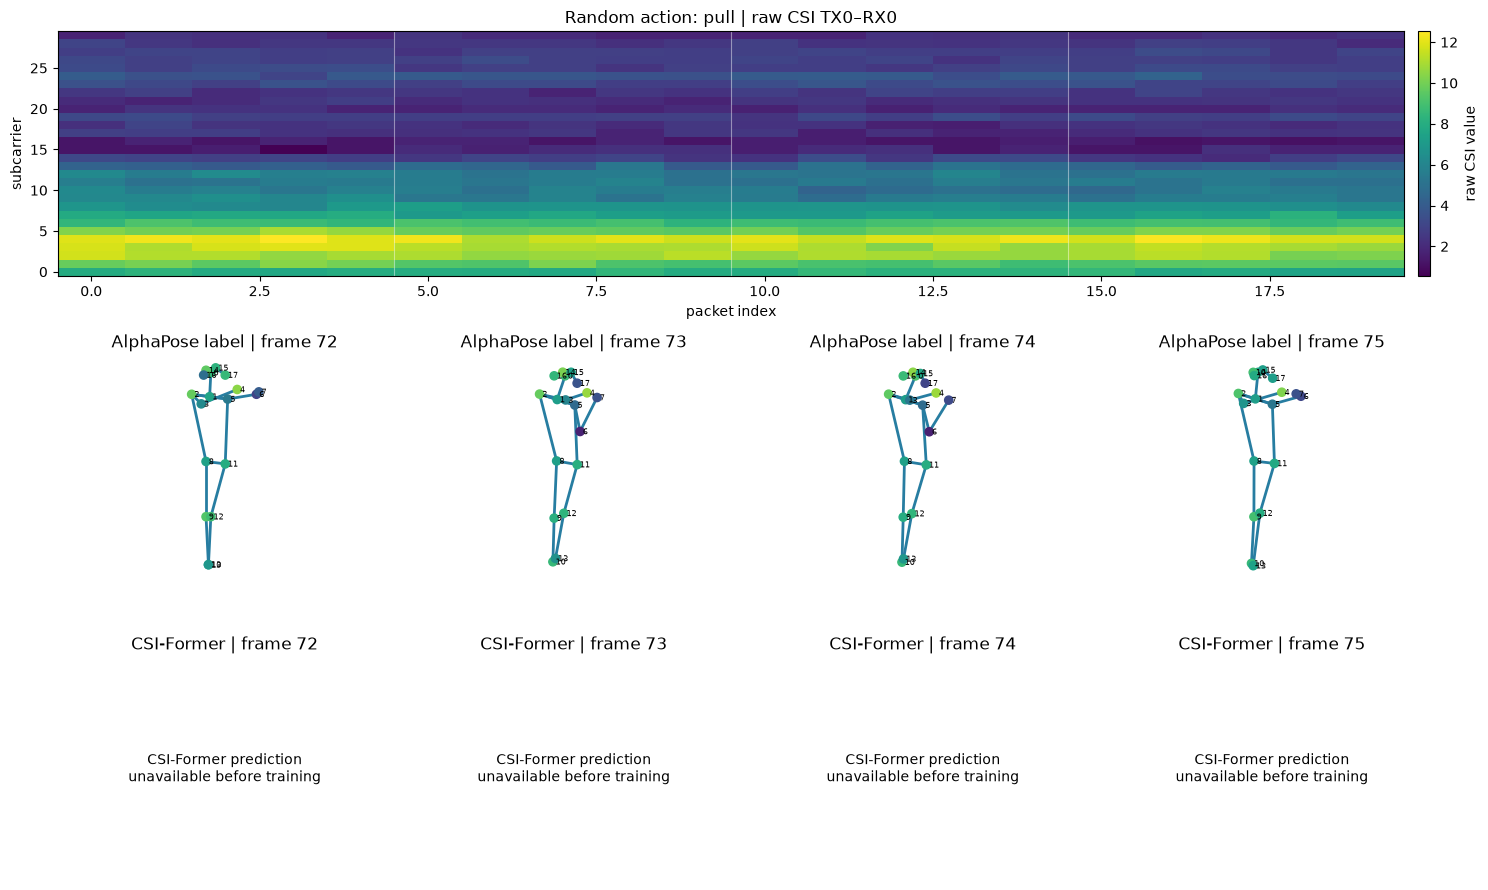

In [10]:
RANDOM_SEED = None  # Use an integer for a repeatable sample.
RANDOM_ACTION = None  # Example: 'run'; None samples any action.
RANDOM_RECORDING = None  # Example: '085'; these IDs represent recordings, not volunteer identity.
RANDOM_SEQUENCE_FRAMES = 4
CSI_FORMER_PREDICTION_FILE = None  # Optional .npz with sample_id [N] and joints [N,18,2].
rng = np.random.default_rng(RANDOM_SEED)
eligible = (wipose_df.groupby(['activity','participant']).size()
            .loc[lambda count: count >= RANDOM_SEQUENCE_FRAMES].reset_index(name='frames'))
if RANDOM_ACTION is not None: eligible=eligible[eligible.activity.eq(RANDOM_ACTION)]
if RANDOM_RECORDING is not None: eligible=eligible[eligible.participant.eq(RANDOM_RECORDING)]
if eligible.empty: raise ValueError('No recording matches RANDOM_ACTION/RANDOM_RECORDING.')
chosen = eligible.iloc[rng.integers(len(eligible))]
random_group = wipose_df[(wipose_df.activity == chosen.activity) &
                          (wipose_df.participant == chosen.participant)].copy()
random_group['frame'] = random_group.sample_id.str.extract(r'-frame(\d+)$')[0].astype(int)
random_group = random_group.sort_values('frame').reset_index(drop=True)
start = int(rng.integers(0, len(random_group)-RANDOM_SEQUENCE_FRAMES+1))
random_rows = random_group.iloc[start:start+RANDOM_SEQUENCE_FRAMES].copy()
random_csi, random_gt, random_conf = [], [], []
for path_text in random_rows.csi_path:
    with h5py.File(path_text,'r') as f:
        raw=np.asarray(f['CSI'][()],dtype=np.float32)
        pose=np.asarray(f['SkeletonPoints'][()],dtype=np.float32).reshape(3,18)
    random_csi.append(raw[TX_INDEX,RX_INDEX].T)
    raw_joints=pose[:2,:].T
    random_gt.append(np.column_stack([480-raw_joints[:,1],raw_joints[:,0]]))
    random_conf.append(pose[2,:])
random_csi=np.concatenate(random_csi); random_gt=np.stack(random_gt); random_conf=np.stack(random_conf)
random_rows['packet_start']=np.arange(len(random_rows))*5; random_rows['packet_end']=random_rows.packet_start+4
display(random_rows[['sample_id','activity','participant','frame','packet_start','packet_end']])
print(f"Action: {chosen.activity} | participant: {chosen.participant} | CSI: {random_csi.shape} | AlphaPose labels: {random_gt.shape}")
prediction_lookup = {}
if CSI_FORMER_PREDICTION_FILE is not None:
    prediction_data=np.load(CSI_FORMER_PREDICTION_FILE,allow_pickle=False)
    prediction_lookup={str(k):v for k,v in zip(prediction_data['sample_id'],prediction_data['joints'])}
fig=plt.figure(figsize=(15,9)); grid=fig.add_gridspec(3,RANDOM_SEQUENCE_FRAMES,height_ratios=[1.1,1,1])
csi_ax=fig.add_subplot(grid[0,:]); heat=csi_ax.imshow(random_csi.T,aspect='auto',origin='lower',cmap='viridis')
for boundary in range(5,len(random_csi),5): csi_ax.axvline(boundary-.5,color='white',alpha=.45,linewidth=.8)
csi_ax.set(title=f"Random action: {chosen.activity} | raw CSI TX{TX_INDEX}–RX{RX_INDEX}",xlabel='packet index',ylabel='subcarrier')
fig.colorbar(heat,ax=csi_ax,label='raw CSI value',fraction=.015,pad=.01)
all_points=[random_gt]
x0,x1=random_gt[:,:,0].min()-25,random_gt[:,:,0].max()+25; y0,y1=random_gt[:,:,1].min()-25,random_gt[:,:,1].max()+25
for column,(row,joints,conf) in enumerate(zip(random_rows.itertuples(),random_gt,random_conf)):
    gt_ax=fig.add_subplot(grid[1,column])
    for a,b in BODY18_EDGES: gt_ax.plot(joints[[a,b],0],joints[[a,b],1],color='#277da1',linewidth=2)
    gt_ax.scatter(joints[:,0],joints[:,1],c=conf,cmap='viridis',vmin=0,vmax=1,s=35,zorder=3)
    for joint_id,(x,y) in enumerate(joints): gt_ax.annotate(str(joint_id),(x,y),xytext=(2,-2),textcoords='offset points',fontsize=6)
    gt_ax.set(title=f'AlphaPose label | frame {row.frame}',xlim=(x0,x1),ylim=(y1,y0),aspect='equal'); gt_ax.axis('off')
    pred_ax=fig.add_subplot(grid[2,column]); prediction=prediction_lookup.get(row.sample_id)
    if prediction is None:
        pred_ax.text(.5,.5,'CSI-Former prediction\nunavailable before training',ha='center',va='center',transform=pred_ax.transAxes)
    else:
        prediction=np.asarray(prediction,dtype=np.float32)
        prediction_display=np.column_stack([480-prediction[:,1],prediction[:,0]])
        for a,b in BODY18_EDGES: pred_ax.plot(prediction_display[[a,b],0],prediction_display[[a,b],1],color='#f3722c',linewidth=2)
        pred_ax.scatter(prediction_display[:,0],prediction_display[:,1],color='#f94144',s=35,zorder=3)
    pred_ax.set(title=f'CSI-Former | frame {row.frame}',xlim=(x0,x1),ylim=(y1,y0),aspect='equal'); pred_ax.axis('off')
plt.tight_layout(); plt.show()

#### Animated random AlphaPose versus CSI-Former comparison
This video uses the same randomly selected recording as the preceding cell, but chooses its highest-motion 40-frame window by default. This avoids clip-level action labels showing only stationary lead-in or recovery frames. AlphaPose camera-derived labels are rendered in blue with confidence-coloured joints. CSI-Former predictions are rendered separately in orange/red only when real predictions are loaded.

In [11]:
from matplotlib import animation
from IPython.display import HTML
RANDOM_VIDEO_FRAMES = min(40, len(random_group))
RANDOM_VIDEO_FPS = 15
RANDOM_VIDEO_WINDOW_MODE = 'most_dynamic'  # Alternatives: 'random'
preview_skeletons=[]
for path_text in random_group.csi_path:
    with h5py.File(path_text,'r') as f: preview_pose=np.asarray(f['SkeletonPoints'][()],dtype=np.float32).reshape(3,18)
    preview_raw=preview_pose[:2,:14].T
    preview_skeletons.append(np.column_stack([480-preview_raw[:,1],preview_raw[:,0]]))
preview_skeletons=np.stack(preview_skeletons)
frame_motion=np.mean(np.linalg.norm(np.diff(preview_skeletons,axis=0),axis=2),axis=1)
if RANDOM_VIDEO_WINDOW_MODE == 'most_dynamic' and RANDOM_VIDEO_FRAMES > 1:
    window_scores=np.convolve(frame_motion,np.ones(RANDOM_VIDEO_FRAMES-1),mode='valid')
    video_start=int(np.argmax(window_scores)); selected_motion=float(window_scores[video_start]/(RANDOM_VIDEO_FRAMES-1))
else:
    video_start=int(rng.integers(0,len(random_group)-RANDOM_VIDEO_FRAMES+1)); selected_motion=float(frame_motion[video_start:video_start+RANDOM_VIDEO_FRAMES-1].mean())
comparison_rows = random_group.iloc[video_start:video_start+RANDOM_VIDEO_FRAMES].copy()
print(f"Video selection: {chosen.activity}, recording {chosen.participant}, frames {comparison_rows.frame.iloc[0]}–{comparison_rows.frame.iloc[-1]}, mean joint motion {selected_motion:.2f} pixels/frame")
comparison_gt, comparison_conf, comparison_csi, comparison_pred = [], [], [], []
for row in comparison_rows.itertuples():
    with h5py.File(row.csi_path,'r') as f:
        raw=np.asarray(f['CSI'][()],dtype=np.float32)
        pose=np.asarray(f['SkeletonPoints'][()],dtype=np.float32).reshape(3,18)
    raw_gt=pose[:2,:].T
    comparison_gt.append(np.column_stack([480-raw_gt[:,1],raw_gt[:,0]]))
    comparison_conf.append(pose[2,:]); comparison_csi.append(raw[TX_INDEX,RX_INDEX].T)
    pred=prediction_lookup.get(row.sample_id)
    comparison_pred.append(None if pred is None else np.column_stack([480-np.asarray(pred)[:,1],np.asarray(pred)[:,0]]))
comparison_gt=np.stack(comparison_gt); comparison_conf=np.stack(comparison_conf); comparison_csi=np.concatenate(comparison_csi)
has_predictions=all(p is not None for p in comparison_pred)
fig,(gt_ax,pred_ax,csi_ax)=plt.subplots(1,3,figsize=(16,5),gridspec_kw={'width_ratios':[1,1,1.7]})
cx0,cx1=comparison_gt[:,:,0].min()-25,comparison_gt[:,:,0].max()+25
cy0,cy1=comparison_gt[:,:,1].min()-25,comparison_gt[:,:,1].max()+25
for axis in (gt_ax,pred_ax): axis.set(xlim=(cx0,cx1),ylim=(cy1,cy0),aspect='equal'); axis.axis('off')
gt_lines=[gt_ax.plot([],[],color='#277da1',linewidth=2.5,label='AlphaPose label' if i==0 else None)[0] for i,_ in enumerate(BODY18_EDGES)]
gt_points=gt_ax.scatter([],[],c=[],cmap='viridis',vmin=0,vmax=1,s=55,zorder=3)
pred_lines=[pred_ax.plot([],[],color='#f3722c',linewidth=2.5,label='CSI-Former' if i==0 else None)[0] for i,_ in enumerate(BODY18_EDGES)]
pred_points=pred_ax.scatter([],[],color='#f94144',s=55,zorder=3)
if not has_predictions: pred_ax.text(.5,.5,'CSI-Former predictions unavailable\nLoad a real prediction file above',ha='center',va='center',transform=pred_ax.transAxes,color='#c1121f',weight='bold')
heat=csi_ax.imshow(comparison_csi.T,aspect='auto',origin='lower',cmap='viridis')
comparison_cursor=csi_ax.axvspan(0,4,color='red',alpha=.25)
csi_ax.set(title=f'Raw CSI TX{TX_INDEX}–RX{RX_INDEX}',xlabel='packet index',ylabel='subcarrier'); fig.colorbar(heat,ax=csi_ax,label='raw CSI value')
def update_random_comparison(i):
    global comparison_cursor
    joints=comparison_gt[i]; conf=comparison_conf[i]; row=comparison_rows.iloc[i]
    for line,(a,b) in zip(gt_lines,BODY18_EDGES): line.set_data(joints[[a,b],0],joints[[a,b],1])
    gt_points.set_offsets(joints); gt_points.set_array(conf)
    gt_ax.set_title(f'AlphaPose camera-derived label\n{row.activity} | frame {row.frame} | mean confidence {conf.mean():.2f}',color='#277da1',weight='bold')
    if has_predictions:
        pred=comparison_pred[i]
        for line,(a,b) in zip(pred_lines,BODY18_EDGES): line.set_data(pred[[a,b],0],pred[[a,b],1])
        pred_points.set_offsets(pred); pred_ax.set_title(f'CSI-Former prediction\n{row.activity} | frame {row.frame}',color='#f3722c',weight='bold')
    else: pred_ax.set_title('CSI-Former prediction',color='#f3722c',weight='bold')
    comparison_cursor.remove(); comparison_cursor=csi_ax.axvspan(i*5,i*5+4,color='red',alpha=.25)
    fig.suptitle(f'Random synchronized comparison | action: {row.activity} | participant: {row.participant}',weight='bold')
    return [*gt_lines,gt_points,*pred_lines,pred_points,comparison_cursor]
random_comparison_video=animation.FuncAnimation(fig,update_random_comparison,frames=len(comparison_rows),interval=1000/RANDOM_VIDEO_FPS,blit=False,repeat=True)
plt.close(fig)
HTML(random_comparison_video.to_html5_video())

Video selection: pull, recording 016, frames 61–100, mean joint motion 7.26 pixels/frame


## 1.2 WiMANS: unlabelled target-domain dataset
WiMANS contains synchronized CSI, video, and categorical multi-user annotations. It does not contain joint coordinates. For HPE, its CSI can support self-supervised target-domain adaptation, while its videos can later produce confidence-filtered pseudo-skeletons. The annotation audit below distinguishes native ground truth from labels that must be derived.

In [12]:
annotation_path = PROJECT_ROOT / 'data/extracted/wimans/annotation.csv'
wimans = pd.read_csv(annotation_path, encoding='utf-8-sig')
display(wimans.head())
display(pd.DataFrame({
    'rows': [len(wimans)], 'columns': [wimans.shape[1]],
    'unique labels': [wimans.label.nunique()],
    'environments': [wimans.environment.nunique()],
    'bands': [wimans.wifi_band.nunique()]
}))
missing = wimans.isna().sum().sort_values(ascending=False)
display(missing[missing.gt(0)].to_frame('missing values'))

,#,label,environment,wifi_band,number_of_users,user_1_location,user_2_location,user_3_location,user_4_location,user_5_location,user_6_location,user_1_activity,user_2_activity,user_3_activity,user_4_activity,user_5_activity,user_6_activity
0,1,act_1_1,classroom,2.4,1,a,NaN,NaN,NaN,NaN,NaN,nothing,NaN,NaN,NaN,NaN,NaN
1,2,act_1_2,classroom,2.4,1,a,NaN,NaN,NaN,NaN,NaN,walk,NaN,NaN,NaN,NaN,NaN
2,3,act_1_3,classroom,2.4,1,a,NaN,NaN,NaN,NaN,NaN,rotation,NaN,NaN,NaN,NaN,NaN
3,4,act_1_4,classroom,2.4,1,a,NaN,NaN,NaN,NaN,NaN,jump,NaN,NaN,NaN,NaN,NaN
4,5,act_1_5,classroom,2.4,1,a,NaN,NaN,NaN,NaN,NaN,wave,NaN,NaN,NaN,NaN,NaN


,rows,columns,unique labels,environments,bands
0,11286,17,11286,3,2


,missing values
user_4_location,6534
user_3_activity,6534
user_3_location,6534
user_2_location,6534
user_1_location,6534
user_2_activity,6534
user_1_activity,6534
user_6_location,6534
user_5_location,6534
user_5_activity,6534


### WiMANS scene and activity distributions
Environment and band balance determine whether a model can be tested across rooms and frequencies. User-count balance matters because the proposed source task is single-person pose estimation. Blank user slots are expected: a one-user record has five unused location/activity columns. The activity plot therefore stacks only nonblank user annotations.

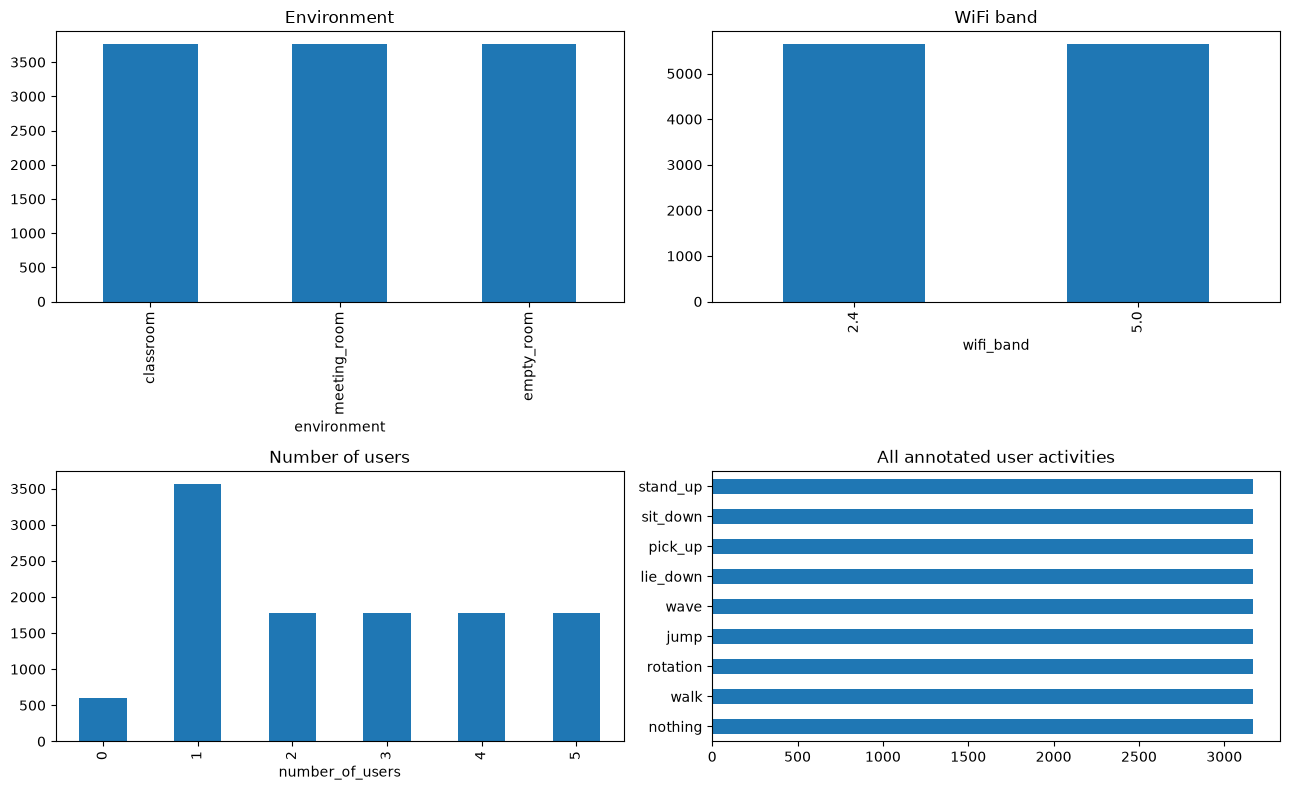

In [13]:
activity_cols = [f'user_{i}_activity' for i in range(1, 7)]
activities = wimans[activity_cols].stack().dropna()
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
wimans.environment.value_counts().plot.bar(ax=axes[0,0], title='Environment')
wimans.wifi_band.astype(str).value_counts().plot.bar(ax=axes[0,1], title='WiFi band')
wimans.number_of_users.value_counts().sort_index().plot.bar(ax=axes[1,0], title='Number of users')
activities.value_counts().sort_values().plot.barh(ax=axes[1,1], title='All annotated user activities')
plt.tight_layout()

### WiMANS modality coverage
Every annotation label should map to CSI amplitude, raw MATLAB CSI, and video by filename stem. This audit reports missing or extra files without loading the 72 GB dataset into memory. The amplitude arrays are the practical input for exploratory statistics; raw MATLAB traces remain available for later phase-aware preprocessing.

In [14]:
wimans_root = PROJECT_ROOT / 'data/extracted/wimans'
labels = set(wimans.label.astype(str))
amp_stems = {p.stem for p in (wimans_root / 'wifi_csi/amp').glob('*.npy')}
mat_stems = {p.stem for p in (wimans_root / 'wifi_csi/mat').glob('*.mat')}
video_stems = {p.stem for p in (wimans_root / 'video').glob('*.mp4')}
coverage = pd.DataFrame({
    'modality': ['annotation', 'amplitude', 'raw MATLAB CSI', 'video'],
    'files/records': [len(labels), len(amp_stems), len(mat_stems), len(video_stems)],
    'missing annotation labels': [0, len(labels-amp_stems), len(labels-mat_stems), len(labels-video_stems)],
    'extra file stems': [0, len(amp_stems-labels), len(mat_stems-labels), len(video_stems-labels)]
})
display(coverage)

,modality,files/records,missing annotation labels,extra file stems
0,annotation,11286,0,0
1,amplitude,11286,0,0
2,raw MATLAB CSI,11286,0,0
3,video,11286,0,0


### WiMANS CSI sample
WiMANS amplitude samples are variable-length arrays shaped `(time, 3, 3, 30)`. The code uses memory mapping for one file, checks finite values, plots one antenna link across time and subcarriers, and records duration in packets. Later preprocessing will crop or pad these sequences to a fixed window without fitting statistics on monitor or test groups.

,value
file,act_10_97.npy
shape,"(2907, 3, 3, 30)"
dtype,float32
minimum,0.0
maximum,179.605118
mean,64.06588
std,28.739796
non-finite values,0


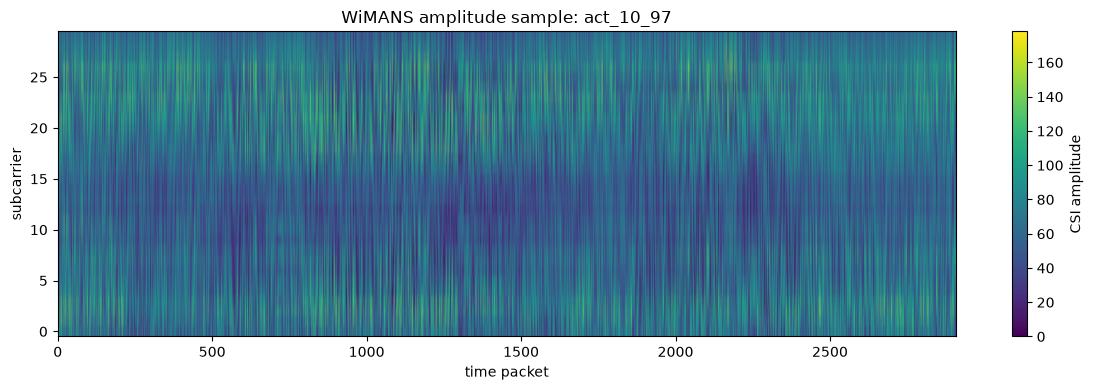

In [15]:
amp_path = next((wimans_root / 'wifi_csi/amp').glob('*.npy'))
amp = np.load(amp_path, mmap_mode='r')
display(pd.Series({
    'file': amp_path.name, 'shape': str(amp.shape), 'dtype': str(amp.dtype),
    'minimum': float(np.nanmin(amp)), 'maximum': float(np.nanmax(amp)),
    'mean': float(np.nanmean(amp)), 'std': float(np.nanstd(amp)),
    'non-finite values': int((~np.isfinite(amp)).sum())
}).to_frame('value'))
plt.figure(figsize=(12, 4))
plt.imshow(amp[:, 0, 0, :].T, aspect='auto', origin='lower')
plt.colorbar(label='CSI amplitude'); plt.xlabel('time packet'); plt.ylabel('subcarrier')
plt.title(f'WiMANS amplitude sample: {amp_path.stem}')
plt.tight_layout()

### Exploration conclusion for HPE
Wi-Pose supplies CSI-to-skeleton supervision but is dominated by adjacent frames, so participant grouping is mandatory. WiMANS supplies target-domain CSI across rooms, bands, activities, and user counts, but no native skeleton ground truth. The strict zero-shot condition must freeze the Wi-Pose-trained model before WiMANS inference. The adaptation condition may use unlabelled WiMANS CSI for masked reconstruction. Any video-derived WiMANS skeletons must be reported as pseudo-labels and kept out of strict zero-shot training.

## 2. Preprocessing

Training input: standardized CSI amplitude with shape `(9, 5, 30)`. Training output: 14 canonical 2D joints with confidence. Deployment output: a `(14, 2)` skeleton. The practical objective is accurate and anatomically plausible pose recovery without a camera at deployment.

### 2.1 Dataset provenance and inspection
Document Wi-Pose and WiMANS, validate schemas after archive review, quantify exclusions, and audit participant/environment splits. Avoid decorative EDA unrelated to the model interface.

### 2.2 Preprocessing and alignment
Explain complex-to-amplitude conversion, antenna-link reshaping, training-only normalization, video/CSI timing alignment, the common 14-joint map, confidence filtering, and canonical coordinates.

### 2.3 Implemented data-readiness artefacts

The final Wi-Pose inventory is split by complete recording/participant identifier with seed `31050`: 96 groups for training, 12 for per-epoch monitoring, and 12 for the untouched final test. Because recordings contain different numbers of frames, the achieved frame counts are close to, but not exactly, 80/10/10. CSI normalization is fitted only on the training frames.

WiMANS is restricted to single-person 5 GHz recordings. Classroom and meeting-room recordings form the unlabelled SSL partition; empty-room recordings form the frozen zero-shot partition. WiMANS has activity metadata but no native skeleton ground truth.

In [16]:
# Run the complete data-readiness stage from the ML_31005 kernel.
from shared.data.prepare_readiness import main as prepare_data

prepare_data()  # split, WiMANS partitions, train-only normalization, quality report

normalization: 5000/132786 training samples
normalization: 10000/132786 training samples
normalization: 15000/132786 training samples
normalization: 20000/132786 training samples
normalization: 25000/132786 training samples
normalization: 30000/132786 training samples
normalization: 35000/132786 training samples
normalization: 40000/132786 training samples
normalization: 45000/132786 training samples
normalization: 50000/132786 training samples
normalization: 55000/132786 training samples
normalization: 60000/132786 training samples
normalization: 65000/132786 training samples
normalization: 70000/132786 training samples
normalization: 75000/132786 training samples
normalization: 80000/132786 training samples
normalization: 85000/132786 training samples
normalization: 90000/132786 training samples
normalization: 95000/132786 training samples
normalization: 100000/132786 training samples
normalization: 105000/132786 training samples
normalization: 110000/132786 training samples
normaliz

In [17]:
readiness = json.loads((PROJECT_ROOT / 'data/manifests/quality_report_v1.json').read_text())
split_info = json.loads((PROJECT_ROOT / 'data/manifests/split_v1.json').read_text())
with np.load(PROJECT_ROOT / 'data/processed/normalization_wipose_train_v1.npz', allow_pickle=False) as z:
    csi_mean, csi_std = z['mean'], z['std']
    fitted_samples = int(z['fitted_samples'])

assert readiness['checks'] == {
    'split_overlap': False,
    'wimans_partition_overlap': False,
    'normalizer_train_only': True,
    'loader_shape_and_finite': True,
}
assert csi_mean.shape == csi_std.shape == (9, 30) and fitted_samples == 132_786

pd.DataFrame({
    'partition': ['train', 'monitor', 'test'],
    'groups': [len(split_info['groups'][p]) for p in ('train', 'monitor', 'test')],
    'frames': [split_info['sample_counts'][p] for p in ('train', 'monitor', 'test')],
})

,partition,groups,frames
0,train,96,132786
1,monitor,12,16169
2,test,12,17645


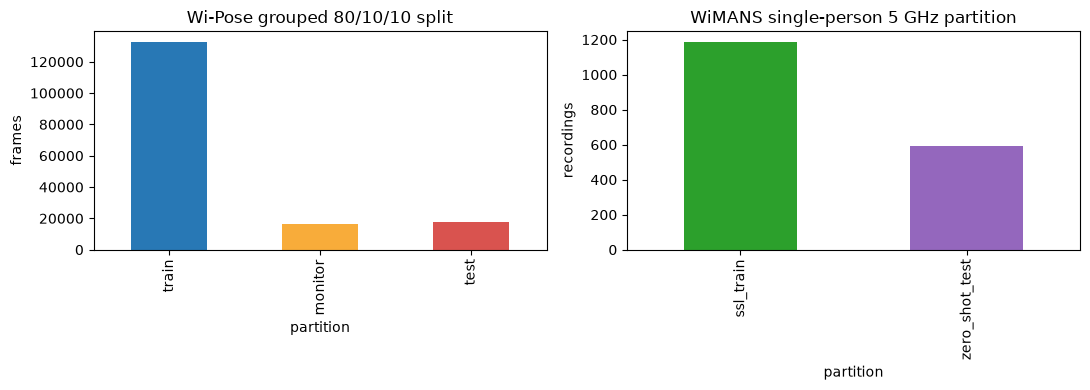

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
pd.Series(split_info['sample_counts']).reindex(['train', 'monitor', 'test']).plot.bar(ax=axes[0], color=['#2878B5', '#F8AC3A', '#D9534F'])
axes[0].set(title='Wi-Pose grouped 80/10/10 split', ylabel='frames', xlabel='partition')
pd.Series(readiness['wimans']['partition_counts']).plot.bar(ax=axes[1], color=['#2CA02C', '#9467BD'])
axes[1].set(title='WiMANS single-person 5 GHz partition', ylabel='recordings', xlabel='partition')
plt.tight_layout()
plt.show()

### 2.4 Model-input transformation

Wi-Pose stores each frame's amplitude as five packets × three transmitters × three receivers × 30 subcarriers. The shared loader rearranges this to nine antenna links × five packets × 30 subcarriers and applies the frozen `[9, 30]` training statistics. The `.npz` source remains unchanged.

No additional temporal smoothing is applied in readiness version 1. A five-packet window is too short for the longer Hampel/Savitzky–Golay/band-pass chain used in the earlier WiSe4Car breathing pipeline, and ACF would remove timing information needed for pose regression. Such filtering should be added only after reconstructing continuous Wi-Pose recordings and validating it as an HPE ablation.

{'sample': 'bend_001-frame001', 'action': 'bend', 'partition': 'monitor', 'raw_csi': (5, 3, 3, 30), 'model_csi': (9, 5, 30), 'source_pose': (18, 2), 'training_pose': (14, 2), 'torso_scale_px': 138.63430786132812}


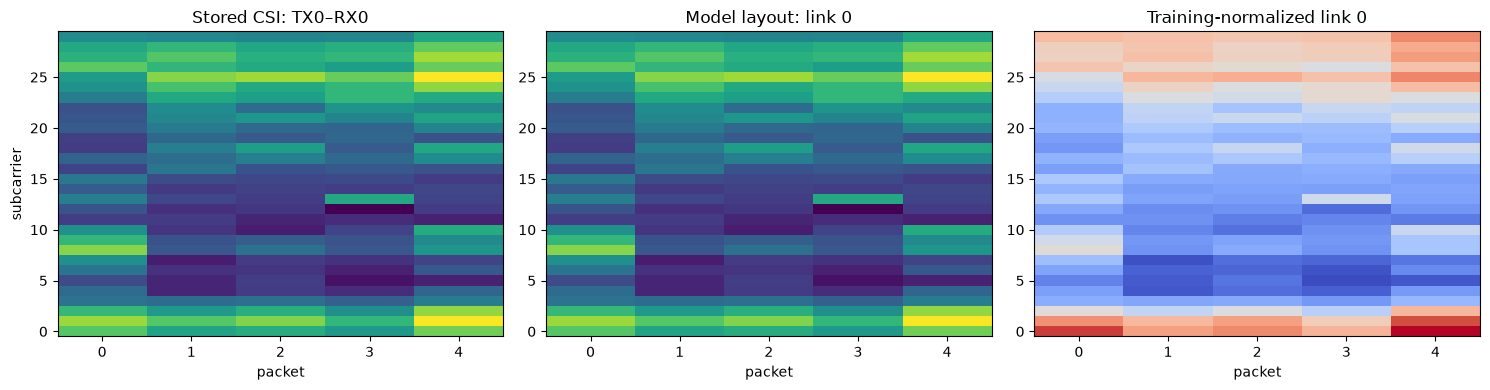

In [19]:
from shared.data.preprocessing import canonicalize_pose, csi_amplitude, reshape_csi_window
from shared.data.skeleton import WIPOSE_TO_BODY_14

# Load one processed sample and reproduce every model-facing transformation.
with (PROJECT_ROOT / 'data/manifests/wipose_split_v1.jsonl').open() as f:
    readiness_sample = json.loads(next(f))
with np.load(readiness_sample['processed_path'], allow_pickle=False) as z:
    raw_csi = z['csi']
    source_joints = z['joints_18_pixel']
    source_confidence = z['confidence_18']
    saved_target = z['joints']

# CSI: [packets, Tx, Rx, subcarriers] -> amplitude -> [links, packets, subcarriers].
model_csi = reshape_csi_window(csi_amplitude(raw_csi))
normalized_csi = (model_csi - csi_mean[:, None, :]) / csi_std[:, None, :]

# Pose: named AlphaPose-18 -> BODY-14 -> hip-centred, torso-normalized target.
indices = list(WIPOSE_TO_BODY_14)
body14_pixels = source_joints[indices]
body14_confidence = source_confidence[indices]
body14_target, torso_scale = canonicalize_pose(body14_pixels, body14_confidence)

assert model_csi.shape == normalized_csi.shape == (9, 5, 30)
assert body14_target.shape == saved_target.shape == (14, 2)
assert np.isfinite(normalized_csi).all() and np.allclose(body14_target, saved_target)
print({
    'sample': readiness_sample['sample_id'],
    'action': readiness_sample['activity'],
    'partition': readiness_sample['partition'],
    'raw_csi': raw_csi.shape,
    'model_csi': model_csi.shape,
    'source_pose': source_joints.shape,
    'training_pose': body14_target.shape,
    'torso_scale_px': float(torso_scale),
})

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=True)
axes[0].imshow(raw_csi[:, 0, 0, :].T, aspect='auto', origin='lower')
axes[0].set(title='Stored CSI: TX0–RX0', xlabel='packet', ylabel='subcarrier')
axes[1].imshow(model_csi[0].T, aspect='auto', origin='lower')
axes[1].set(title='Model layout: link 0', xlabel='packet')
axes[2].imshow(normalized_csi[0].T, aspect='auto', origin='lower', cmap='coolwarm')
axes[2].set(title='Training-normalized link 0', xlabel='packet')
plt.tight_layout()
plt.show()

### 2.5 Named joint mapping and reusable dataset views

The source skeleton is retained as AlphaPose-18. The training target is selected by the explicit name-based BODY-14 mapping below; eye and ear joints remain available for audit plots. Partition-specific datasets inherit the shared manifest loader so preprocessing stays in one implementation.

In [20]:
from shared.data.skeleton import BODY_14_EDGES, BODY_14_JOINTS

pd.DataFrame({
    'target_index': range(len(BODY_14_JOINTS)),
    'target_joint': BODY_14_JOINTS,
    'alphapose_source_index': WIPOSE_TO_BODY_14,
})

,target_index,target_joint,alphapose_source_index
0,0,nose,0
1,1,neck,1
2,2,right_shoulder,2
3,3,right_elbow,3
4,4,right_wrist,4
5,5,left_shoulder,5
6,6,left_elbow,6
7,7,left_wrist,7
8,8,right_hip,8
9,9,right_knee,9


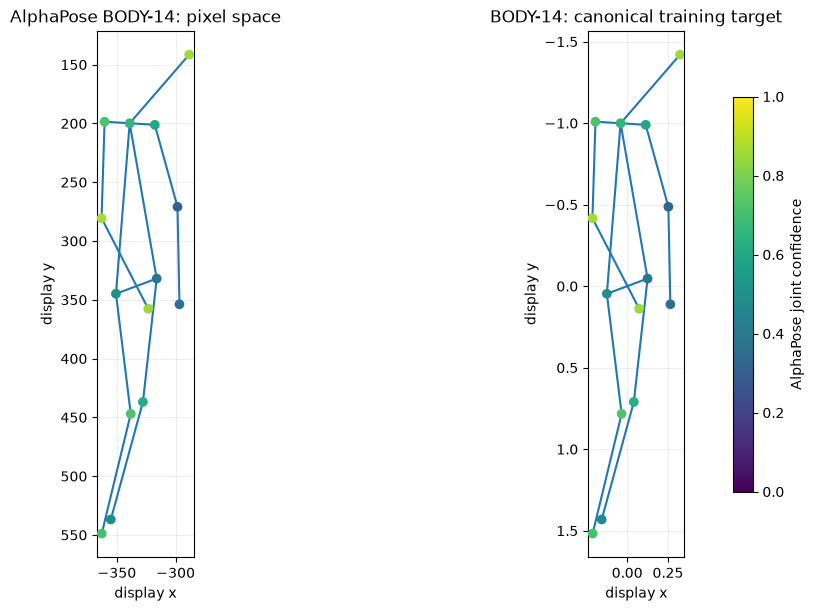

In [21]:
def display_pose(joints):
    # Rotate the released camera frame clockwise for an upright display only.
    return np.column_stack((-joints[:, 1], joints[:, 0]))

def draw_body14(ax, joints, title):
    joints = display_pose(joints)
    for start, end in BODY_14_EDGES:
        ax.plot(joints[[start, end], 0], joints[[start, end], 1], color='tab:blue')
    points = ax.scatter(joints[:, 0], joints[:, 1], c=body14_confidence, cmap='viridis', vmin=0, vmax=1, zorder=3)
    ax.set(title=title, aspect='equal', xlabel='display x', ylabel='display y')
    ax.invert_yaxis()
    ax.grid(alpha=.2)
    return points

fig, axes = plt.subplots(1, 2, figsize=(11, 6), constrained_layout=True)
points = draw_body14(axes[0], body14_pixels, 'AlphaPose BODY-14: pixel space')
draw_body14(axes[1], body14_target, 'BODY-14: canonical training target')
fig.colorbar(points, ax=axes, label='AlphaPose joint confidence', shrink=.75)
plt.show()

**How to read these graphs.** Blue lines connect anatomical neighbours in the BODY-14 skeleton. Marker colour encodes the original AlphaPose confidence: dark purple is low confidence and yellow is high confidence, as shown by the shared colour bar. The left graph retains camera pixel position and scale; the right graph subtracts the hip midpoint and divides by torso length, which is the target supplied to the model. Both graphs are rotated clockwise only for an upright human-readable display—the stored coordinates and training target are unchanged.

In [22]:
from shared.data.datasets import ManifestPoseDataset, load_manifest
from shared.data.preprocessing import CSINormalizer

normalizer = CSINormalizer(csi_mean, csi_std)
split_manifest = PROJECT_ROOT / 'data/manifests/wipose_split_v1.jsonl'
split_records = load_manifest(split_manifest)

class WiPosePartition(ManifestPoseDataset):
    def __init__(self, partition):
        records = [row for row in split_records if row['partition'] == partition]
        if not records:
            raise ValueError(f'No samples in {partition!r}')
        super().__init__(records, normalizer.transform)
        self.partition = partition

datasets = {name: WiPosePartition(name) for name in ('train', 'monitor', 'test')}
dataset_sizes = {name: len(data) for name, data in datasets.items()}
assert dataset_sizes == split_info['sample_counts']
dataset_sizes

{'train': 132786, 'monitor': 16169, 'test': 17645}

In [23]:
import torch
from torch.utils.data import DataLoader

batch = next(iter(DataLoader(datasets['train'], batch_size=32, shuffle=True, num_workers=0)))
assert batch['csi'].shape == (32, 9, 5, 30)
assert batch['joints'].shape == (32, 14, 2)
assert batch['confidence'].shape == (32, 14)
assert torch.isfinite(batch['csi']).all() and torch.isfinite(batch['joints']).all()
{key: tuple(value.shape) for key, value in batch.items() if isinstance(value, torch.Tensor)}

{'csi': (32, 9, 5, 30), 'joints': (32, 14, 2), 'confidence': (32, 14)}

## 3. Model
Display the residual CNN, masked autoencoder, regression head, tensor transformations, parameter counts, and the implementation corresponding to each equation.

### 3.1 Learning objective
Compare confidence-weighted Smooth L1 coordinate loss, bone-vector loss, and symmetry regularization. Explain why minimizing coordinate error alone may produce implausible skeletons.

## 4. Condition A — source-only strict zero-shot
Train only on Wi-Pose, select by the per-epoch monitor participant, evaluate once on the Wi-Pose final participant, freeze weights, and infer on WiMANS.

## 5. Condition B — label-free target-domain adaptation
Pretrain by masked CSI reconstruction using allowed unlabeled WiMANS environments, fine-tune using Wi-Pose labels, and evaluate on the held-out WiMANS environment. This is not strict zero-shot learning.

### 5.1 Training behavior across both conditions
Plot training and monitor loss/metrics per epoch. Explain checkpoint selection, early stopping, generalization gaps, automatic batch sizing, mixed precision, and two-GPU DDP.

## 6. Evaluation and error analysis
Report NME, PCK, PCK-AUC, bone-length error, per-joint and per-activity behavior, retained pseudo-label coverage, seed mean/std, and representative success/failure skeletons.

### 6.1 Loss versus practical objective
Identify cases where a lower training loss does not yield a more useful pose. Compare numerical accuracy with anatomical validity and cross-domain reliability.

## 7. Reflection, limitations, and implementation log
Discuss AlphaPose/RTMPose pseudo-ground-truth noise, CSI hardware and environment shift, canonical-coordinate limitations, single-person scope, failed attempts, AI assistance, verification, and remaining knowledge gaps.